<a href="https://colab.research.google.com/github/AishuShans/Task-4-AI-ML-intern-/blob/main/Task_4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

Loading the dataset

In [4]:
df = pd.read_csv('Cancer_Data.csv')


In [5]:
df = df.drop('id', axis=1)

Step 1 :Mapping the 'cancer Types' to numerical values: 'B' -> 0, 'M' -> 1

In [7]:
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

Separating features (X) and target (y)

In [9]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']


In [10]:
print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("\nFirst 5 rows of the dataframe:")
print(df.head())

Shape of features (X): (569, 31)
Shape of target (y): (569,)

First 5 rows of the dataframe:
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  

Step 2 : Train/Test Split and Standardize Features

Splitting the data into training and testing sets (80% train, 20% test)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Initializing the StandardScaler

In [12]:
scaler = StandardScaler()

Fitting the scaler on the training features and transform both training and testing features

In [13]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.11/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [14]:
print("\nShape of scaled training features:", X_train_scaled.shape)
print("Shape of scaled testing features:", X_test_scaled.shape)


Shape of scaled training features: (455, 31)
Shape of scaled testing features: (114, 31)


Step 3 : Fitting a Logistic Regression Model

Initialize the Logistic Regression model

In [15]:
logistic_model = LogisticRegression(random_state=42)

Fit the model on the scaled training data

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer # Import SimpleImputer

# ... (your existing code) ...

# Before scaling, create and apply the imputer
imputer = SimpleImputer(strategy='mean') # Replace NaNs with the mean
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Now scale the imputed data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# ... (rest of your code) ...

/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [18]:
logistic_model.fit(X_train_scaled, y_train)

print("\nLogistic Regression model trained successfully!")


Logistic Regression model trained successfully!


 Evaluating with Confusion Matrix, Precision, Recall, ROC-AUC

Make predictions on the scaled test data

In [19]:
y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

Calculate the confusion matrix

In [20]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)


Confusion Matrix:
 [[70  1]
 [ 2 41]]


Calculate precision

In [21]:
precision = precision_score(y_test, y_pred)
print("\nPrecision:", precision)


Precision: 0.9761904761904762


Calculate recall

In [22]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9534883720930233


Calculate ROC-AUC score

In [23]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.99737962659679


Plot the ROC curve

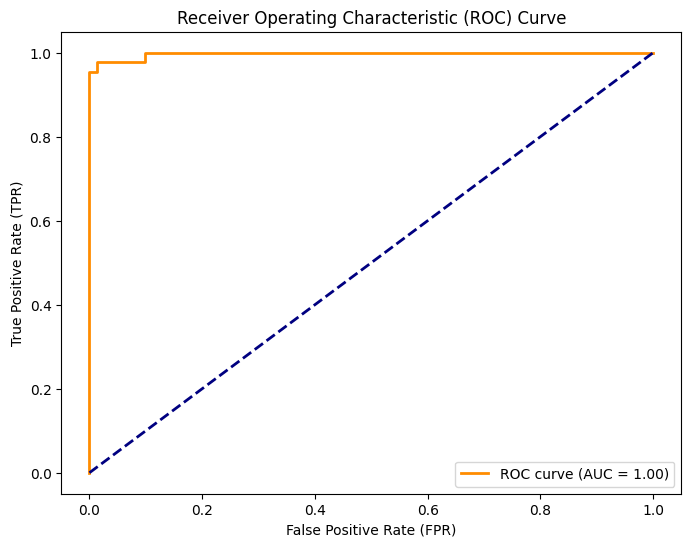

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

Step 5 :Tuning Threshold and Explaining Sigmoid Function

In [25]:
custom_threshold = 0.4
y_pred_threshold = (y_prob >= custom_threshold).astype(int)

Evaluating with the new threshold

In [26]:
conf_matrix_threshold = confusion_matrix(y_test, y_pred_threshold)
precision_threshold = precision_score(y_test, y_pred_threshold)
recall_threshold = recall_score(y_test, y_pred_threshold)

In [27]:
print(f"\nEvaluation with threshold = {custom_threshold}:")
print("Confusion Matrix:\n", conf_matrix_threshold)
print("Precision:", precision_threshold)
print("Recall:", recall_threshold)


Evaluation with threshold = 0.4:
Confusion Matrix:
 [[70  1]
 [ 1 42]]
Precision: 0.9767441860465116
Recall: 0.9767441860465116
